# Netflix Content Type Prediction Model

### Auspify Technologies - Machine Learning Internship
### Task 2

This project develops a machine learning classification model
to predict whether a Netflix title is a Movie or TV Show.

Author: B S Vanisha Babu

In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Saving Dataset.csv to Dataset.csv
Dataset loaded successfully!
Shape: (8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [2]:
print("Dataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB
None

Column Names:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Missing Values:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0


In [3]:
features = ['release_year', 'rating', 'country', 'listed_in']
target = 'type'

X = df[features].copy()
y = df[target].copy()

print("Selected Features:")
for feature in features:
    print("-", feature)

print("\nTarget:")
print("-", target)

print("\nFeature Data:")
X.head()

Selected Features:
- release_year
- rating
- country
- listed_in

Target:
- type

Feature Data:


,release_year,rating,country,listed_in
0,2020,PG-13,United States,Documentaries
1,2021,TV-MA,France,"Crime TV Shows, International TV Shows, TV Act..."
2,2021,TV-MA,United States,"TV Dramas, TV Horror, TV Mysteries"
3,2021,TV-PG,Brazil,"Children & Family Movies, Comedies"
4,1993,TV-MA,United States,"Dramas, Independent Movies, International Movies"


In [4]:
X_encoded = pd.get_dummies(X, columns=['rating', 'country', 'listed_in'])

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

X_encoded.head()

Original shape: (8790, 4)
Encoded shape: (8790, 614)


,release_year,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,2020,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2021,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2021,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,2021,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1993,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Target classes:", label_encoder.classes_)
print("Encoded target values:", sorted(set(y_encoded)))

Target classes: ['Movie' 'TV Show']
Encoded target values: [np.int64(0), np.int64(1)]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (7032, 614)
Testing data shape: (1758, 614)


In [7]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_logistic))

Predictions generated successfully!
Number of predictions: 1758


In [10]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 99.2 %


In [11]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [12]:
y_pred_tree = decision_tree.predict(X_test)

print("Decision Tree predictions generated successfully!")
print("Number of predictions:", len(y_pred_tree))

Decision Tree predictions generated successfully!
Number of predictions: 1758


In [13]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", round(tree_accuracy * 100, 2), "%")

Decision Tree Accuracy: 98.81 %


In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [15]:
y_pred_forest = random_forest.predict(X_test)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_forest))

Random Forest predictions generated successfully!
Number of predictions: 1758


In [16]:
from sklearn.metrics import accuracy_score

forest_accuracy = accuracy_score(y_test, y_pred_forest)

print("Random Forest Accuracy:", round(forest_accuracy * 100, 2), "%")

Random Forest Accuracy: 97.21 %


In [17]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy (%)': [
        round(logistic_accuracy * 100, 2),
        round(tree_accuracy * 100, 2),
        round(forest_accuracy * 100, 2)
    ]
})

model_results

,Model,Accuracy (%)
0,Logistic Regression,99.20
1,Decision Tree,98.81
2,Random Forest,97.21


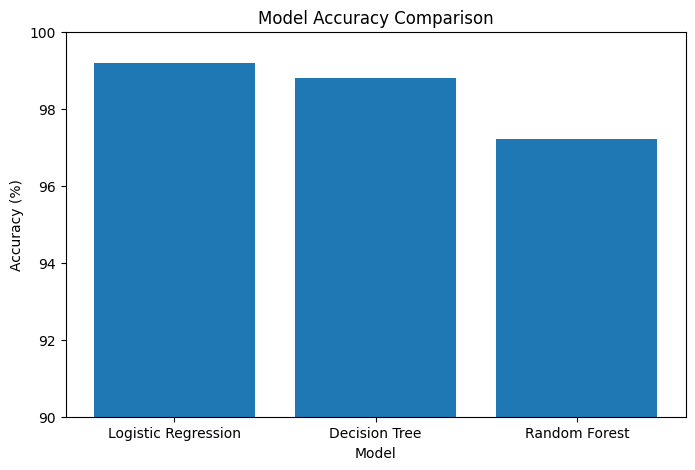

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_results['Model'],
    model_results['Accuracy (%)']
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(90, 100)

plt.show()

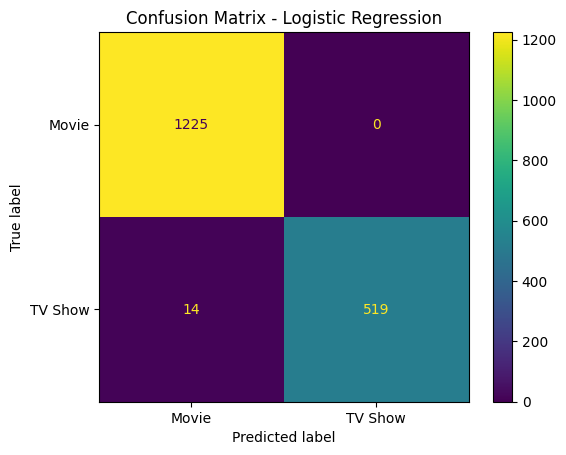

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [20]:
from sklearn.metrics import classification_report

print("Classification Report - Logistic Regression")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=label_encoder.classes_
))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

       Movie       0.99      1.00      0.99      1225
     TV Show       1.00      0.97      0.99       533

    accuracy                           0.99      1758
   macro avg       0.99      0.99      0.99      1758
weighted avg       0.99      0.99      0.99      1758



### Evaluation Summary

The Logistic Regression model achieved an accuracy of 99.20% on the test dataset.

The classification report shows that the model performed well for both Movies and TV Shows, with an F1-score of 0.99 for both classes. The model achieved a recall of 1.00 for Movies and 0.97 for TV Shows.

Overall, the results show that the selected features were useful for predicting the content type of Netflix titles.

## Conclusion

In this project, a machine learning model was developed to predict whether a Netflix title is a Movie or TV Show.

The dataset was prepared by selecting relevant features and converting categorical variables into numerical form using one-hot encoding. Three classification models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.

The test accuracies were:

- Logistic Regression: 99.20%
- Decision Tree: 98.81%
- Random Forest: 97.21%

Among the three models tested, Logistic Regression achieved the highest test accuracy for this dataset and feature set.

The project demonstrated a complete machine learning workflow including feature selection, data encoding, train-test splitting, model training, prediction, performance evaluation, and model comparison.

## Technologies Used

- Python
- Pandas
- Scikit-learn
- Matplotlib
- Google Colab
- Machine Learning Classification Algorithms

## Project Workflow

1. Load the Netflix dataset
2. Inspect the dataset and check for missing values
3. Select relevant features
4. Encode categorical features
5. Encode the target variable
6. Split the data into training and testing sets
7. Train Logistic Regression, Decision Tree, and Random Forest models
8. Generate predictions
9. Evaluate model performance
10. Compare the accuracy of the models